# Oprimization of LSTM and GRU

In [2]:
from scipy.io import loadmat
from numpy import asarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy.matlib
from scipy import signal
from scipy.signal import welch
from scipy.stats import entropy
from scipy.fft import fft, fftfreq
import os
import glob
from warnings import warn
from sklearn import metrics
plt.rc('font',family='Times New Roman')
import warnings 
warnings.filterwarnings('ignore')

In [4]:
def make_dataset(data_src):
    files = glob.glob(data_src)
    dataset_df = []
    for file in files:
        if os.path.isfile(file) and file.endswith(".csv"):
            # read only the 2nd column (index 1)
            col = pd.read_csv(file, header=None, usecols=[1])
            dataset_df.append(col)
    
    dataset = pd.concat(dataset_df, ignore_index=True, axis=1)
    return dataset.T

## Dataset

In [7]:
data_path = ("../data/Wave Data/") # path to the 4 folders.
A  = make_dataset(os.path.join(data_path,  'A/*'))
B  = make_dataset(os.path.join(data_path,  'B/*'))
C  = make_dataset(os.path.join(data_path,  'C/*'))
D  = make_dataset(os.path.join(data_path,  'D/*'))
E  = make_dataset(os.path.join(data_path,  'E/*'))

'''non_seizure = make_dataset(os.path.join('../data/spectrograms/class_0', '*.csv'))
seizure = make_dataset(os.path.join('../data/spectrograms/class_1', '*.csv'))'''

"non_seizure = make_dataset(os.path.join('../data/spectrograms/class_0', '*.csv'))\nseizure = make_dataset(os.path.join('../data/spectrograms/class_1', '*.csv'))"

In [8]:
normal = pd.concat([A, B, C, D]).reset_index(drop=True).to_numpy()
ictal = E.to_numpy()

In [11]:
'''normal = pd.concat(non_seizure).reset_index(drop=True).to_numpy()
ictal  = pd.concat(seizure).reset_index(drop=True).to_numpy()'''

'normal = pd.concat(non_seizure).reset_index(drop=True).to_numpy()\nictal  = pd.concat(seizure).reset_index(drop=True).to_numpy()'

In [13]:
num_samples =500 # Length of input segment
###########################################
fs =  173.61; # Sampling freq.

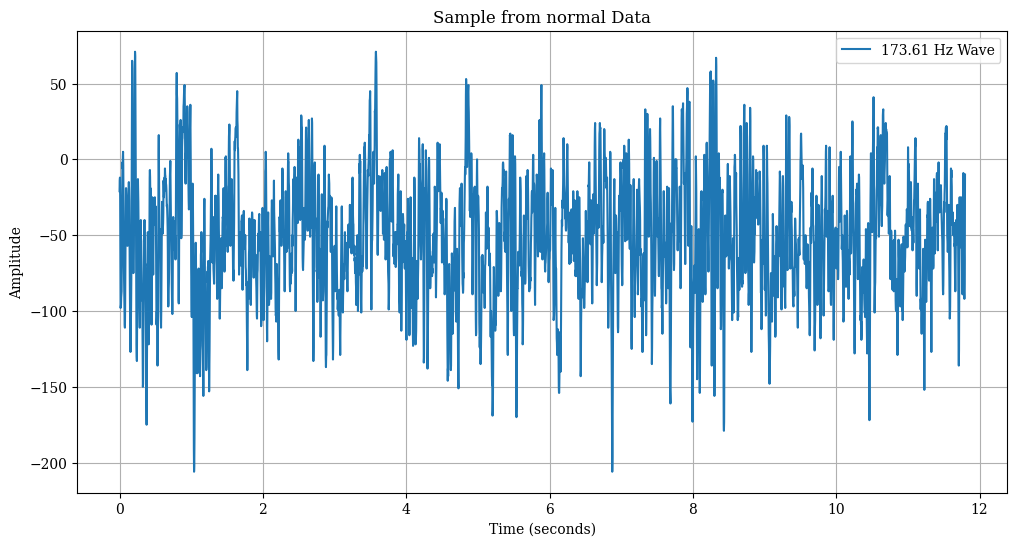

In [15]:
plt.rcParams["font.family"] = "DejaVu Serif"
num_points = 4097
sampling_rate = 2 * fs
t = np.arange(num_points) / sampling_rate
signal = normal[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label=f"{fs} Hz Wave")
plt.title("Sample from normal Data")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

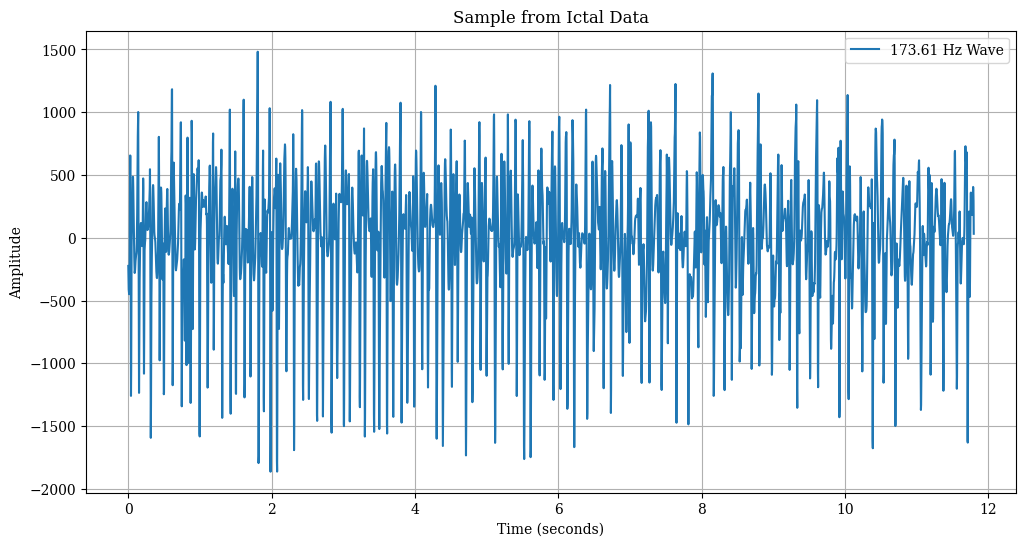

In [45]:
signal = ictal[0]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, signal, label=f"{fs} Hz Wave")
plt.title("Sample from Ictal Data")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
normal_labels = np.zeros(len(normal))
ictal_labels = np.ones(len(ictal))

# Combine data and labels
X = np.concatenate((normal, ictal), axis=0)
Y = np.concatenate((normal_labels, ictal_labels), axis=0)

print("Dataset features size:", X.shape)
print("Dataset labels size:", Y.shape)

Dataset features size: (500, 4097)
Dataset labels size: (500,)


In [21]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, 
                                                    shuffle = True, stratify = Y, random_state = 42)

In [25]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, shuffle = True, stratify = y_train, random_state=42)

In [27]:
mean = X_train.mean(axis=(0, 1), keepdims=True)  
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8  

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std
X_val_norm = (X_val - mean) / std

In [29]:
X_train = np.reshape(X_train_norm, (X_train_norm.shape[0], X_train_norm.shape[1], 1))
X_test = np.reshape(X_test_norm, (X_test_norm.shape[0], X_test_norm.shape[1], 1))
X_val = np.reshape(X_val_norm, (X_val_norm.shape[0], X_val_norm.shape[1], 1))

In [31]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.config.experimental import list_physical_devices, set_memory_growth
from tensorflow import device
from tensorflow.keras.callbacks import ModelCheckpoint
from hyperopt import tpe, hp, fmin, Trials
import numpy as np

## Optimize LSTM

In [39]:
timesteps = 4097
features = 1
def objective(params):
    model = Sequential([
        LSTM(params['units0'], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=params['rd0']),  
        LSTM(params['units1'], return_sequences=True, recurrent_dropout=params['rd1']),
        LSTM(params['units2'], return_sequences=False, recurrent_dropout=params['rd2']),
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'), 
        Dropout(params['dropout1']),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    with device('/GPU:0'):
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size = 20,
            callbacks= [early_stopping],
            verbose = 2
        )
    val_loss = history.history['val_loss'][-1]
    return val_loss

In [41]:
space = {
    'units0': hp.choice('units0', [16, 32, 64, 128]),
    'units1': hp.choice('units1', [16, 32, 64, 128]),
    'units2': hp.choice('units2', [16, 32, 64, 128]),
    'rd0': hp.uniform('rd0', 0.1, 0.5),
    'rd1': hp.uniform('rd1', 0.1, 0.5),
    'rd2': hp.uniform('rd2', 0.1, 0.5),
    'dropout0': hp.uniform('dropout0', 0.1, 0.5),
    'dropout1': hp.uniform('dropout1', 0.1, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-2)),
    'dense_units': hp.choice('dense_units', [16, 32, 64, 128]),
}

In [43]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=5,
    trials=trials
)

print("Best hyperparameters:", best)

Epoch 1/50                                                                      

16/16 - 151s - 9s/step - accuracy: 0.6476 - loss: 0.6920 - val_accuracy: 0.7714 - val_loss: 0.6891

Epoch 2/50                                                                      

16/16 - 136s - 8s/step - accuracy: 0.7206 - loss: 0.6900 - val_accuracy: 0.8857 - val_loss: 0.6861

Epoch 3/50                                                                      

16/16 - 136s - 8s/step - accuracy: 0.8032 - loss: 0.6879 - val_accuracy: 0.9143 - val_loss: 0.6829

Epoch 4/50                                                                      

16/16 - 132s - 8s/step - accuracy: 0.8222 - loss: 0.6844 - val_accuracy: 0.9143 - val_loss: 0.6795

Epoch 5/50                                                                      

16/16 - 145s - 9s/step - accuracy: 0.8476 - loss: 0.6809 - val_accuracy: 0.9143 - val_loss: 0.6756

Epoch 6/50                                                                      

16/16 - 

KeyboardInterrupt: 

In [ ]:
print(best)

In [86]:
vals = {
    'units0': [16, 32, 64, 128],
    'units1': [16, 32, 64, 128],
    'units2': [16, 32, 64, 128],
    'dense_units': [16, 32, 64, 128],
}

In [87]:
model = Sequential([
    LSTM(vals['units0'][best['units0']], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=best['rd0']),  
    LSTM(vals['units1'][best['units1']], return_sequences=True, recurrent_dropout=best['rd1']),
    LSTM(vals['units2'][best['units2']], return_sequences=False, recurrent_dropout=best['rd2']),
    Dropout(best['dropout0']),
    Dense(vals['dense_units'][best['dense_units']], activation='relu'), 
    Dropout(best['dropout1']),
    Dense(1, activation='sigmoid') # <-- FIX: Was 'softmax', must be 'sigmoid'
])
model.compile(optimizer=Adam(learning_rate = best['lr']), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/Optimized_LSTM.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [88]:
with device('/GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size = 20,
        callbacks= [early_stopping, checkpoint]
    )


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 6s/step - accuracy: 0.1712 - loss: 0.6923 - val_accuracy: 0.2000 - val_loss: 0.6814
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.1921 - loss: 0.6792 - val_accuracy: 0.2000 - val_loss: 0.6631
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step - accuracy: 0.1633 - loss: 0.6613 - val_accuracy: 0.2000 - val_loss: 0.6228
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 115s 7s/step - accuracy: 0.1889 - loss: 0.6186 - val_accuracy: 0.2000 - val_loss: 0.5216
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 110s 7s/step - accuracy: 0.2038 - loss: 0.5421 - val_accuracy: 0.2000 - val_loss: 0.3870
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 6s/step - accuracy: 0.2017 - loss: 0.4400 - val_accuracy: 0.2000 - val_loss: 0.3640
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 102s 6s/step - accuracy: 0.1630 - loss: 0.3270 - val_accuracy: 0.2000 - val_loss: 0.3166
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 103s 6s/step - accuracy: 0.2006 - loss: 0.3659 - val_accuracy: 0.2000 - v

In [89]:
model.load_weights('../weights/Optimized_LSTM.weights.h5')
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2346 - loss: 0.2663   
Test Loss: 0.24605149030685425
Test Accuracy: 0.20000000298023224


In [90]:
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step   


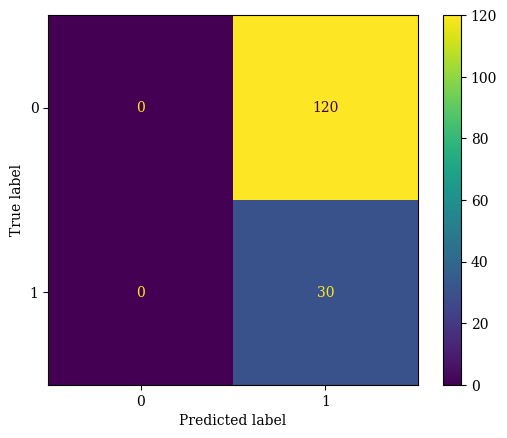

In [95]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
display_labels = [0, 1]  # Adjust based on your class labels
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()

In [96]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       120
         1.0       0.20      1.00      0.33        30

    accuracy                           0.20       150
   macro avg       0.10      0.50      0.17       150
weighted avg       0.04      0.20      0.07       150



## Optimize GRU

In [40]:
def objective_GRU(params):
    model = Sequential([
        GRU(params['units0'], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=params['rd0']),  
        GRU(params['units1'], return_sequences=True, recurrent_dropout=params['rd1']),
        GRU(params['units2'], return_sequences=False, recurrent_dropout=params['rd2']),
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'), 
        Dropout(params['dropout1']),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    with device('/GPU:0'):
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size = 20,
            callbacks= [early_stopping],
            verbose = 0
        )
    val_loss = history.history['val_loss'][-1]
    return val_loss

In [41]:
trials_GRU = Trials()

best_GRU = fmin(
    fn=objective_GRU,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials_GRU
)

print("Best hyperparameters:", best_GRU)

 20%|████████▏                                | 4/20 [04:51<19:24, 72.78s/trial, best loss: 0.07104545831680298]


KeyboardInterrupt: 

In [ ]:
print(best_GRU)

In [ ]:
model_GRU = Sequential([
    GRU(vals['units0'][best_GRU['units0']], return_sequences=True, input_shape=(timesteps, features),recurrent_dropout=best['rd0']),  
    GRU(vals['units1'][best_GRU['units1']], return_sequences=True, recurrent_dropout=best['rd1']),
    GRU(vals['units2'][best_GRU['units2']], return_sequences=False, recurrent_dropout=best['rd2']),
    Dropout(best_GRU['dropout0']),
    Dense(vals['dense_units'][best_GRU['dense_units']], activation='relu'), 
    Dropout(best_GRU['dropout1']),
    Dense(1, activation='sigmoid')
])
model_GRU.compile(optimizer=Adam(learning_rate = best_GRU['lr']), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/Optimized_GRU.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [ ]:
with device('/GPU:0'):
    history = model_GRU.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size = 20,
        callbacks= [early_stopping, checkpoint]
    )

In [ ]:
model_GRU.load_weights('../weights/Optimized_GRU.weights.h5')
test_loss, test_accuracy = model_GRU.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

In [ ]:
y_pred = model_GRU.predict(X_test)

In [ ]:
# Converting to class labels
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
display_labels = [0, 1, 2]  # Adjust based on your class labels
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Scikit-learn imports
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# TensorFlow and Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv2D, MaxPooling2D, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import device

# Hyperopt imports
from hyperopt import tpe, hp, fmin, Trials

In [28]:
# Define image properties and paths
IMAGE_SIZE = (128, 128)  # Images will be resized to this
BATCH_SIZE = 20
TRAIN_DIR = '../data/spectrograms_split/train'
VAL_DIR = '../data/spectrograms_split/val'

# Create data generators
# This will also normalize the pixel values to be between 0 and 1
datagen = ImageDataGenerator(rescale=1./255)

In [30]:
print("Loading training data...")
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',      # For class_0 and class_1 folders
    color_mode='grayscale'    # Use 'rgb' if your spectrograms are in color
)

print("\nLoading validation data...")
validation_generator = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale'
)

Loading training data...
Found 320 images belonging to 2 classes.

Loading validation data...
Found 80 images belonging to 2 classes.


In [32]:
input_shape = (IMAGE_SIZE[0], IMAGE_SIZE[1], 1)

In [34]:
def objective_lstm(params):
    model = Sequential([
        # 1. CNN layers to extract features from the image
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # 2. Reshape the output of CNNs to be a sequence for the RNN
        Reshape((-1, 64)), # Reshapes to (timesteps, features) for the LSTM

        # 3. LSTM layers
        LSTM(params['units0'], return_sequences=True, recurrent_dropout=params['rd0']),
        LSTM(params['units1'], return_sequences=False, recurrent_dropout=params['rd1']),
        
        # 4. Dense layers for classification
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'),
        Dropout(params['dropout1']),
        Dense(1, activation='sigmoid') # Use 'sigmoid' for binary classification
    ])
    
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    with device('/GPU:0'):
        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=50,
            callbacks=[early_stopping],
            verbose=0
        )
        
    val_loss = history.history['val_loss'][-1]
    print(f"Trial finished with val_loss: {val_loss}")
    return val_loss

In [36]:
def objective_gru(params):
    model = Sequential([
        # 1. CNN layers
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # 2. Reshape for RNN
        Reshape((-1, 64)), 

        # 3. GRU layers
        GRU(params['units0'], return_sequences=True, recurrent_dropout=params['rd0']),  
        GRU(params['units1'], return_sequences=False, recurrent_dropout=params['rd1']),
        
        # 4. Dense layers
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'), 
        Dropout(params['dropout1']),
        Dense(1, activation='sigmoid') # Use 'sigmoid' for binary classification
    ])
    
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    with device('/GPU:0'):
        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=50,
            callbacks=[early_stopping],
            verbose=0
        )
        
    val_loss = history.history['val_loss'][-1]
    print(f"Trial finished with val_loss: {val_loss}")
    return val_loss

In [38]:
space = {
    'units0': hp.choice('units0', [32, 64, 128]),
    'units1': hp.choice('units1', [32, 64, 128]),
    'rd0': hp.uniform('rd0', 0.1, 0.5),
    'rd1': hp.uniform('rd1', 0.1, 0.5),
    'dropout0': hp.uniform('dropout0', 0.1, 0.5),
    'dropout1': hp.uniform('dropout1', 0.1, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-2)),
    'dense_units': hp.choice('dense_units', [32, 64, 128]),
}

In [40]:
print("\n--- Starting LSTM Optimization ---")
trials_lstm = Trials()
best_lstm_params = fmin(
    fn=objective_lstm,
    space=space,
    algo=tpe.suggest,
    max_evals=20,  # You can increase this for a more thorough search
    trials=trials_lstm
)
print("\nBest LSTM hyperparameters:", best_lstm_params)


--- Starting LSTM Optimization ---
Trial finished with val_loss: 0.5620383024215698                                
Trial finished with val_loss: 0.39073237776756287                               
Trial finished with val_loss: 0.5653426647186279                                
Trial finished with val_loss: 0.5678600072860718                                
Trial finished with val_loss: 0.5484307408332825                                
Trial finished with val_loss: 0.5651103854179382                                
Trial finished with val_loss: 0.5650267601013184                                
Trial finished with val_loss: 0.5634176135063171                                
Trial finished with val_loss: 0.5458180904388428                                
Trial finished with val_loss: 0.5537559390068054                                
Trial finished with val_loss: 0.5535993576049805                                
Trial finished with val_loss: 0.5644787549972534                         

In [42]:
print("\n--- Starting GRU Optimization ---")
trials_gru = Trials()
best_gru_params = fmin(
    fn=objective_gru,
    space=space,
    algo=tpe.suggest,
    max_evals=20, # You can increase this for a more thorough search
    trials=trials_gru
)
print("\nBest GRU hyperparameters:", best_gru_params)


--- Starting GRU Optimization ---
Trial finished with val_loss: 0.4376498758792877                                
Trial finished with val_loss: 0.4451942443847656                                
Trial finished with val_loss: 0.5636388063430786                                
Trial finished with val_loss: 0.5682546496391296                                
Trial finished with val_loss: 0.5688228607177734                                
Trial finished with val_loss: 0.3556656241416931                                
Trial finished with val_loss: 0.5705457329750061                                
Trial finished with val_loss: 0.5694462656974792                                
Trial finished with val_loss: 0.570086658000946                                 
Trial finished with val_loss: 0.5702463984489441                                
Trial finished with val_loss: 0.397472083568573                                 
Trial finished with val_loss: 0.4593435823917389                          

--- Building final optimized LSTM model ---
--- Training final optimized LSTM model ---
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5999 - loss: 0.6766 - val_accuracy: 0.7500 - val_loss: 0.6119
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7860 - loss: 0.5680 - val_accuracy: 0.7500 - val_loss: 0.5723
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7596 - loss: 0.5615 - val_accuracy: 0.7500 - val_loss: 0.5727
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7325 - loss: 0.6216 - val_accuracy: 0.7500 - val_loss: 0.5725
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7668 - loss: 0.5756 - val_accuracy: 0.7500 - val_loss: 0.5708
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7550 - loss: 0.5829 - val_accuracy: 0.7500 - val_loss: 0.5704
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7677 - loss: 0.5785 - val_accuracy: 0.7500 - val_loss: 0.5698
Epoch 8/50
16/16 ━━━━━━━━━━━━━

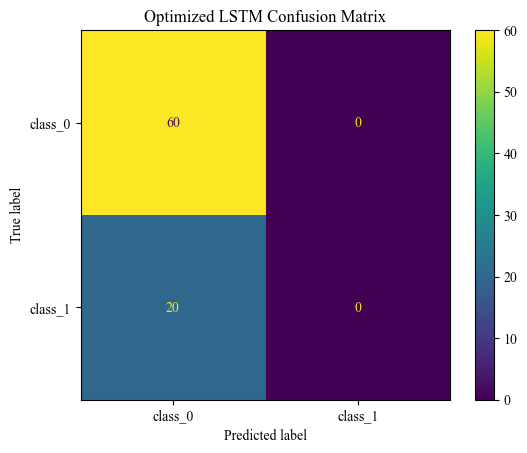


--- Building final optimized GRU model ---
--- Training final optimized GRU model ---
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 962ms/step - accuracy: 0.6111 - loss: 0.6506 - val_accuracy: 0.7500 - val_loss: 0.6255
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 914ms/step - accuracy: 0.7794 - loss: 0.5874 - val_accuracy: 0.7500 - val_loss: 0.5848
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 912ms/step - accuracy: 0.7386 - loss: 0.5851 - val_accuracy: 0.7500 - val_loss: 0.5670
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 942ms/step - accuracy: 0.7738 - loss: 0.5578 - val_accuracy: 0.7500 - val_loss: 0.5634
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 917ms/step - accuracy: 0.7659 - loss: 0.5603 - val_accuracy: 0.7500 - val_loss: 0.5630
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 926ms/step - accuracy: 0.7401 - loss: 0.5777 - val_accuracy: 0.7500 - val_loss: 0.5623
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 934ms/step - accuracy: 0.7911 - loss: 0.5238 - val_accuracy: 0.7500 - val_loss: 0.5679
Epoch 8/50

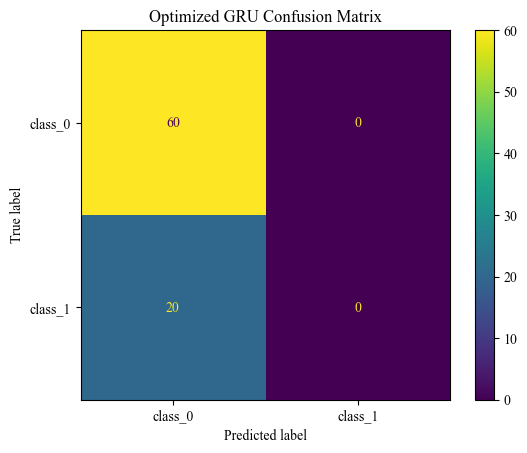

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv2D, MaxPooling2D, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Helper dictionary for hyperopt's choices ---
vals = {
    'units0': [32, 64, 128],
    'units1': [32, 64, 128],
    'dense_units': [32, 64, 128],
}

# ==========================================================
# 1. Train and Evaluate the BEST LSTM Model
# ==========================================================
print("--- Building final optimized LSTM model ---")

# Create the model with the best parameters found by fmin
model_lstm = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Reshape((-1, 64)),
    LSTM(vals['units0'][best_lstm_params['units0']], return_sequences=True, recurrent_dropout=best_lstm_params['rd0']),  
    LSTM(vals['units1'][best_lstm_params['units1']], return_sequences=False, recurrent_dropout=best_lstm_params['rd1']),
    Dropout(best_lstm_params['dropout0']),
    Dense(vals['dense_units'][best_lstm_params['dense_units']], activation='relu'), 
    Dropout(best_lstm_params['dropout1']),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer=Adam(learning_rate=best_lstm_params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks to save the weights of this specific model
checkpoint_lstm = ModelCheckpoint(
    '../weights/Optimized_LSTM_spectrogram.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True
)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # Increased patience for final training

print("--- Training final optimized LSTM model ---")
history_lstm = model_lstm.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50, # Train for more epochs on the final model
    callbacks=[early_stopping, checkpoint_lstm]
)

# --- Evaluate Final LSTM Model ---
print("\n--- Evaluating final LSTM model ---")
model_lstm.load_weights('../weights/Optimized_LSTM_spectrogram.weights.h5') # Load the best weights from this run

validation_generator.reset()
y_pred_prob_lstm = model_lstm.predict(validation_generator)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype("int32")
y_true = validation_generator.classes

print("\nLSTM Classification Report:")
print(classification_report(y_true, y_pred_lstm, target_names=validation_generator.class_indices.keys()))

cm_lstm = confusion_matrix(y_true, y_pred_lstm)
cm_display_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=validation_generator.class_indices.keys())
cm_display_lstm.plot()
plt.title("Optimized LSTM Confusion Matrix")
plt.show()


# ==========================================================
# 2. Train and Evaluate the BEST GRU Model
# ==========================================================
print("\n--- Building final optimized GRU model ---")
model_gru = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Reshape((-1, 64)),
    GRU(vals['units0'][best_gru_params['units0']], return_sequences=True, recurrent_dropout=best_gru_params['rd0']),
    GRU(vals['units1'][best_gru_params['units1']], return_sequences=False, recurrent_dropout=best_gru_params['rd1']),
    Dropout(best_gru_params['dropout0']),
    Dense(vals['dense_units'][best_gru_params['dense_units']], activation='relu'),
    Dropout(best_gru_params['dropout1']),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer=Adam(learning_rate=best_gru_params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_gru = ModelCheckpoint(
    '../weights/Optimized_GRU_spectrogram.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True
)

print("--- Training final optimized GRU model ---")
history_gru = model_gru.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stopping, checkpoint_gru]
)

# --- Evaluate Final GRU Model ---
print("\n--- Evaluating final GRU model ---")
model_gru.load_weights('../weights/Optimized_GRU_spectrogram.weights.h5')

validation_generator.reset()
y_pred_prob_gru = model_gru.predict(validation_generator)
y_pred_gru = (y_pred_prob_gru > 0.5).astype("int32")
# y_true is the same as before

print("\nGRU Classification Report:")
print(classification_report(y_true, y_pred_gru, target_names=validation_generator.class_indices.keys()))

cm_gru = confusion_matrix(y_true, y_pred_gru)
cm_display_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=validation_generator.class_indices.keys())
cm_display_gru.plot()
plt.title("Optimized GRU Confusion Matrix")
plt.show()

## Better LSTM with Preprocessing

In [45]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# TensorFlow and Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.config.experimental import list_physical_devices, set_memory_growth
from tensorflow import device

# Hyperopt imports
from hyperopt import tpe, hp, fmin, Trials

# Suppress warnings
warnings.filterwarnings('ignore')
plt.rc('font',family='Times New Roman')

In [47]:
def make_dataset(data_src):
    """Loads all CSV files from a directory and returns a DataFrame."""
    files = glob.glob(data_src)
    dataset_df = []
    
    for file in files:
        if os.path.isfile(file) and file.endswith(".csv"):
            # read only the 2nd column (index 1)
            col = pd.read_csv(file, header=None, usecols=[1])
            dataset_df.append(col)
    
    if not dataset_df:
        print(f"Warning: No CSV files found in {data_src}")
        return pd.DataFrame()
        
    dataset = pd.concat(dataset_df, ignore_index=True, axis=1)
    return dataset.T

In [49]:
# --- 1. Load Data ---
data_path = ("../data/Wave Data/") # path to the 5 folders.
A = make_dataset(os.path.join(data_path, 'A/*'))
B = make_dataset(os.path.join(data_path, 'B/*'))
C = make_dataset(os.path.join(data_path, 'C/*'))
D = make_dataset(os.path.join(data_path, 'D/*'))
E = make_dataset(os.path.join(data_path, 'E/*')) # Seizure data

# --- 2. Combine and Create Labels ---
# Normal (non-seizure) data
normal = pd.concat([A, B, C, D]).reset_index(drop=True).to_numpy()
# Ictal (seizure) data
ictal = E.to_numpy()

normal_labels = np.zeros(len(normal))
ictal_labels = np.ones(len(ictal))

# Combine data and labels
X = np.concatenate((normal, ictal), axis=0)
Y = np.concatenate((normal_labels, ictal_labels), axis=0)

print(f"Total X shape: {X.shape}")
print(f"Total Y shape: {Y.shape}")

# --- 3. Split Data ---
# Create Test set (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, shuffle=True, stratify=Y, random_state=42
)

# Create Validation set from remaining training data (10% of 70% = 7% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, shuffle=True, stratify=y_train, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

Total X shape: (500, 4097)
Total Y shape: (500,)
X_train shape: (315, 4097)
y_train shape: (315,)
X_val shape:   (35, 4097)
y_val shape:   (35,)
X_test shape:  (150, 4097)
y_test shape:  (150,)


In [51]:
# --- 4. Normalize Data ---
# Use StandardScaler: fit ONLY on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Data scaled using StandardScaler (fit on train data only).")

# --- 5. Reshape for RNN ---
# Reshape data from (samples, timesteps) to (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Reshaped X_train: {X_train.shape}")

# Define model input parameters
timesteps = X_train.shape[1]  # Should be 4097
features = X_train.shape[2]   # Should be 1

Data scaled using StandardScaler (fit on train data only).
Reshaped X_train: (315, 4097, 1)


In [53]:
def objective(params):
    model = Sequential([
        LSTM(params['units0'], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=params['rd0']),  
        LSTM(params['units1'], return_sequences=True, recurrent_dropout=params['rd1']),
        LSTM(params['units2'], return_sequences=False, recurrent_dropout=params['rd2']),
        Dropout(params['dropout0']),
        Dense(params['dense_units'], activation='relu'), 
        Dropout(params['dropout1']),
        # FIX: Use 'sigmoid' for binary_crossentropy
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=params['lr']), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    with device('/GPU:0'):
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size = 20,
            callbacks= [early_stopping],
            verbose = 0
        )
        
    val_loss = history.history['val_loss'][-1]
    return val_loss

In [55]:
# Note: Reduced choices to 3 to match the 'vals' dict later
space = {
    'units0': hp.choice('units0', [32, 64, 128]),
    'units1': hp.choice('units1', [32, 64, 128]),
    'units2': hp.choice('units2', [32, 64, 128]),
    'rd0': hp.uniform('rd0', 0.1, 0.5),
    'rd1': hp.uniform('rd1', 0.1, 0.5),
    'rd2': hp.uniform('rd2', 0.1, 0.5),
    'dropout0': hp.uniform('dropout0', 0.1, 0.5),
    'dropout1': hp.uniform('dropout1', 0.1, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-2)),
    'dense_units': hp.choice('dense_units', [32, 64, 128]),
}

In [ ]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials
)

print("Best hyperparameters:", best)

  0%|                                    | 0/20 [00:00<?, ?trial/s, best loss=?]

In [ ]:
# Helper dictionary to map 'best' integer indices back to layer sizes
vals = {
    'units0': [32, 64, 128],
    'units1': [32, 64, 128],
    'units2': [32, 64, 128],
    'dense_units': [32, 64, 128],
}

# Build the final model with optimized parameters
model = Sequential([
    LSTM(vals['units0'][best['units0']], return_sequences=True, input_shape=(timesteps, features), recurrent_dropout=best['rd0']),  
    LSTM(vals['units1'][best['units1']], return_sequences=True, recurrent_dropout=best['rd1']),
    LSTM(vals['units2'][best['units2']], return_sequences=False, recurrent_dropout=best['rd2']),
    Dropout(best['dropout0']),
    Dense(vals['dense_units'][best['dense_units']], activation='relu'), 
    Dropout(best['dropout1']),
    # FIX: Use 'sigmoid' for binary_crossentropy
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate = best['lr']), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/Optimized_LSTM.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

model.summary()

In [ ]:
with device('/GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size = 20,
        callbacks= [early_stopping, checkpoint]
    )

In [ ]:
print("--- Loading best weights for evaluation ---")
model.load_weights('../weights/Optimized_LSTM.weights.h5')

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Get predictions (probabilities)
y_pred_prob = model.predict(X_test)

In [ ]:
# FIX: Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype("int32")

# FIX: y_test is already 1D, no argmax needed
y_test_classes = y_test

# Compute confusion matrix
cm = confusion_matrix(y_test_classes, y_pred)

# Display confusion matrix
# FIX: display_labels should be for a binary problem
display_labels = [0, 1] 
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()
plt.title("Optimized LSTM Confusion Matrix")
plt.show()

# Print classification report
print("\n--- Classification Report ---")
print(classification_report(y_test_classes, y_pred))

In [ ]:
import numpy as np

# --- You can change this index to test different samples ---
sample_index = 0
# ------------------------------------------------------------

# Get a single sample from the test set (it's already normalized and reshaped)
sample = X_test[np.newaxis, sample_index]

# Get the corresponding true label (it's a 1D array)
true_label_index = y_test[sample_index].astype("int32")

# Use the 'model' to predict.
prediction_prob = model.predict(sample)[0][0]

# Get the predicted class index by thresholding
predicted_label_index = (prediction_prob > 0.5).astype("int32")

# Define the class names
class_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']

# Print the results
print(f"--- Testing Sample #{sample_index} ---")
print(f"Model Prediction: {class_names[predicted_label_index]} (Prob: {prediction_prob:.4f})")
print(f"Actual Label:     {class_names[true_label_index]}")

if predicted_label_index == true_label_index:
    print("\nResult: Correctly Identified!")
else:
    print("\nResult: Incorrectly Identified.")